# DREIDING conformational energetics: reproducing Tables XI and XII of the 1990 paper

DREIDING (Mayo, Olafson & Goddard III, *J. Phys. Chem.* **94**, 8897, 1990)
is a *generic* force field: it deliberately refuses to tabulate parameters
per bond, angle or torsion type. Bond lengths are sums of atomic radii, one
force constant covers every bond and another every angle, and the torsion
barriers come from six numbers assigned by hybridization. The paper's own
test of whether that austerity survives contact with reality is Section
IV.B: single-bond rotational barriers (Table XI) and conformational
energies (Table XII).

This notebook reproduces both tables with the `xnn` implementation. Every
number below is a *relaxed* scan -- the dihedral is constrained and every
other degree of freedom minimized -- exactly as the paper describes ("geometry
optimizations were carried out using BIOGRAF ... with Fletcher-Powell
minimization"), with the paper's standard options: harmonic bonds, the
harmonic-cosine angle form, the single-term torsion of eq 13, spectroscopic
inversions, Lennard-Jones 12-6 nonbonds and **no charges**.

Two things are worth watching as the tables fill in.

* Where `xnn` lands relative to the paper's **calculated** column tests the
  rule engine end to end: a wrong hybridization branch, a wrong bond-order
  test or a mis-split barrier would move these numbers by whole kcal/mol.
* Where DREIDING lands relative to **experiment** is a property of the force
  field, not of this implementation. Some rows are excellent and some are
  badly wrong in ways the paper itself flags. Reproducing the failures
  faithfully matters as much as reproducing the successes.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
import math
import time

import numpy as np
import matplotlib.pyplot as plt
import torch

torch.set_default_dtype(torch.float64)

from ase import Atoms
from ase.constraints import FixInternals
from ase.optimize import BFGS
from rdkit import Chem
from rdkit.Chem import AllChem

import xnn
from xnn.common.deploy import XNNCalculator
from xnn.common.models import ForceStressOutput
from xnn.ffnn.common.typing import perceive_bonds
from xnn.ffnn.models import Dreiding, MolecularTopology, read_dreiding
from xnn.ffnn.models.dreiding import RULE_IDS

EV_TO_KCAL = 23.060547830619026      # ase energies are in eV
print("xnn:", xnn.__version__, "| torch:", torch.__version__)

xnn: 0.2.0 | torch: 2.5.1+cu121


## 1. Building a DREIDING model from a SMILES string

`Dreiding.from_atoms` does the whole setup: RDKit perceives the
connectivity and bond orders, the SMARTS templates in the parameter file
assign DREIDING atom types, and the rule engine turns types + bonds +
orders into every valence term. Nothing bonded is looked up in a table.

In [2]:
def embed(smiles, seed=0xC0FFEE):
    '''SMILES -> (RDKit mol with 3D coordinates, ase.Atoms).'''
    mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    AllChem.EmbedMolecule(mol, randomSeed=seed)
    AllChem.MMFFOptimizeMolecule(mol)          # a sane starting geometry only
    conf = mol.GetConformer()
    pos = np.array([list(conf.GetAtomPosition(i))
                    for i in range(mol.GetNumAtoms())])
    z = [a.GetAtomicNum() for a in mol.GetAtoms()]
    return mol, Atoms(numbers=z, positions=pos)


mol, atoms = embed("CCO")
model = Dreiding.from_atoms(mol, "dreiding", cutoff=20.0)
top = model.topology
print("ethanol")
print("  types       ", top.types)
print("  bonds       ", top.bonds)
print("  bond orders ", top.bond_orders)
print(f"  generated    {len(top.angles)} angles, "
      f"{model.dihedral_index.shape[1]} torsion terms, "
      f"{model.inversion_index.shape[1] // 3} inversion centers")
lib = read_dreiding("dreiding")
print(f"  C-O R0 = {lib.radius['C_3']} + {lib.radius['O_3']} - {lib.delta} = "
      f"{lib.radius['C_3'] + lib.radius['O_3'] - lib.delta:.3f} A   (eq 6)")

ethanol
  types        ['C_3', 'C_3', 'O_3', 'H_', 'H_', 'H_', 'H_', 'H_', 'H__HB']
  bonds        [(0, 1), (0, 3), (0, 4), (0, 5), (1, 2), (1, 6), (1, 7), (2, 8)]
  bond orders  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  generated    13 angles, 12 torsion terms, 0 inversion centers
  C-O R0 = 0.77 + 0.66 - 0.01 = 1.420 A   (eq 6)


## 2. Relaxed torsional scans

For a barrier, the dihedral is driven in steps and everything else relaxed
at each step. Two details matter for getting this right:

* the initial rotation must move the whole fragment on one side of the
  central bond, not a single atom, or the constrained minimization starts
  from a badly distorted structure;
* the rotatable bond must be a **single, acyclic** bond. Picking the C=C of
  propene instead of the C-C would measure the 45 kcal/mol double-bond
  barrier of eq 16 rather than the ~1 kcal/mol single-bond barrier the
  table is about.

In [3]:
def side_mask(mol, a2, a3):
    '''Atoms lying on the a3 side of the a2-a3 bond.'''
    seen, stack = {a3}, [a3]
    while stack:
        x = stack.pop()
        for nb in mol.GetAtomWithIdx(x).GetNeighbors():
            i = nb.GetIdx()
            if i != a2 and i not in seen:
                seen.add(i)
                stack.append(i)
    return [i in seen for i in range(mol.GetNumAtoms())]


def pick_quad(mol):
    '''A dihedral (i, j, k, l) about the first single, acyclic heavy bond.'''
    for want_single in (True, False):
        for b in mol.GetBonds():
            i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
            if want_single and (b.GetBondTypeAsDouble() != 1.0 or b.IsInRing()):
                continue
            ai, aj = mol.GetAtomWithIdx(i), mol.GetAtomWithIdx(j)
            if ai.GetAtomicNum() == 1 or aj.GetAtomicNum() == 1:
                continue
            if ai.GetDegree() < 2 or aj.GetDegree() < 2:
                continue
            ni = [x.GetIdx() for x in ai.GetNeighbors() if x.GetIdx() != j]
            nj = [x.GetIdx() for x in aj.GetNeighbors() if x.GetIdx() != i]
            if ni and nj:
                return (ni[0], i, j, nj[0])
    raise ValueError("no rotatable bond found")


def relaxed_scan(smiles, n=25, fmax=1e-3, model=None, mol=None, atoms=None):
    '''Relaxed torsion profile (deg, kcal/mol above the minimum).'''
    if mol is None:
        mol, atoms = embed(smiles)
    if model is None:
        model = Dreiding.from_atoms(mol, "dreiding", cutoff=20.0)
    quad = pick_quad(mol)
    mask = side_mask(mol, quad[1], quad[2])
    calc = XNNCalculator(ForceStressOutput(model), cutoff=20.0)
    ref = atoms.copy()
    ref.calc = calc
    BFGS(ref, logfile=None).run(fmax=fmax, steps=600)
    phis, es = [], []
    for k in range(n):
        phi = 360.0 * k / (n - 1)
        a = ref.copy()
        a.calc = calc
        a.set_dihedral(*quad, phi, mask=mask)
        a.set_constraint(FixInternals(dihedrals_deg=[[phi, list(quad)]],
                                      epsilon=1e-8))
        BFGS(a, logfile=None).run(fmax=fmax, steps=600)
        phis.append(phi)
        es.append(a.get_potential_energy() * EV_TO_KCAL)
    es = np.array(es) - min(es)
    return np.array(phis), es, quad


phi, prof, quad = relaxed_scan("CC")
print(f"ethane, dihedral {quad}: barrier {prof.max():.3f} kcal/mol "
      f"(paper Table XI: 2.896 calculated, 2.882 measured)")

ethane, dihedral (2, 0, 1, 5): barrier 2.896 kcal/mol (paper Table XI: 2.896 calculated, 2.882 measured)


## 3. Table XI: single-bond rotational barriers

The paper's Table XI lists, for each molecule, the experimental barrier and
the one DREIDING calculates. The `xnn` column below is produced entirely
from the rules -- no barrier was fitted or looked up.

In [4]:
# molecule, SMILES, experimental barrier, DREIDING barrier (paper Table XI)
TABLE_XI = [
    ("CH3-CH3",       "CC",     2.882, 2.896),
    ("CH3-CH2CH3",    "CCC",    3.400, 3.376),
    ("CH3-CH(CH3)2",  "CC(C)C", 3.900, 3.995),
    ("CH3-CH2F",      "CCF",    3.287, 3.172),
    ("CH3-CH2Cl",     "CCCl",   3.680, 3.487),
    ("CH3-NH2",       "CN",     1.980, 2.085),
    ("CH3-NHCH3",     "CNC",    3.620, 2.916),
    ("CH3-OH",        "CO",     0.373, 2.117),
    ("CH3-OCH3",      "COC",    2.630, 3.034),
    ("CH3-SH",        "CS",     0.445, 2.376),
    ("CH3-SCH3",      "CSC",    2.099, 2.902),
    ("CH2=CH-CH3",    "C=CC",   1.995, 0.753),
    ("CH3-CH=O",      "CC=O",   1.143, 0.948),
    ("CH3-C(OH)=O",   "CC(O)=O", 0.481, 1.026),
]

t0 = time.time()
rows, profiles = [], {}
for name, smiles, exp, paper in TABLE_XI:
    phi, prof, quad = relaxed_scan(smiles)
    profiles[name] = (phi, prof)
    rows.append((name, prof.max(), paper, exp))
print(f"[{time.time() - t0:.0f} s for {len(rows)} relaxed scans]\n")

print(f"{'molecule':16s} {'xnn':>8s} {'DREIDING':>9s} {'xnn-paper':>10s} "
      f"{'experiment':>11s} {'DREIDING-exp':>13s}")
print("-" * 72)
for name, mine, paper, exp in rows:
    print(f"{name:16s} {mine:8.3f} {paper:9.3f} {mine - paper:+10.3f} "
          f"{exp:11.3f} {paper - exp:+13.3f}")
print("-" * 72)
d_impl = np.array([abs(m - p) for _, m, p, _ in rows])
d_phys = np.array([abs(p - e) for _, _, p, e in rows])
print(f"{'mean |difference|':16s} {'':8s} {'':9s} {d_impl.mean():10.3f} "
      f"{'':11s} {d_phys.mean():13.3f}")
print(f"{'max  |difference|':16s} {'':8s} {'':9s} {d_impl.max():10.3f} "
      f"{'':11s} {d_phys.max():13.3f}")

[54 s for 14 relaxed scans]

molecule              xnn  DREIDING  xnn-paper  experiment  DREIDING-exp
------------------------------------------------------------------------
CH3-CH3             2.896     2.896     -0.000       2.882        +0.014
CH3-CH2CH3          3.368     3.376     -0.008       3.400        -0.024
CH3-CH(CH3)2        3.998     3.995     +0.003       3.900        +0.095
CH3-CH2F            3.172     3.172     -0.000       3.287        -0.115
CH3-CH2Cl           3.483     3.487     -0.004       3.680        -0.193
CH3-NH2             2.088     2.085     +0.003       1.980        +0.105
CH3-NHCH3           2.883     2.916     -0.033       3.620        -0.704
CH3-OH              2.117     2.117     +0.000       0.373        +1.744
CH3-OCH3            2.973     3.034     -0.061       2.630        +0.404
CH3-SH              2.376     2.376     -0.000       0.445        +1.931
CH3-SCH3            2.893     2.902     -0.009       2.099        +0.803
CH2=CH-CH3          0.

The two rightmost statistics say different things.

**`xnn` vs the paper's DREIDING column** is an implementation check, and it
is tight: the rule engine, the barrier splitting of eq 13 and every energy
term together reproduce the published barriers to a few hundredths of a
kcal/mol across fourteen molecules spanning rules (a), (b), (h), (i) and
(j). Residual differences at this level are a matter of how completely each
minimization converged, not of the force field.

**DREIDING vs experiment** is the force field's own accuracy, and the paper
is candid about it. The alcohol and thiol rows are the striking failures:
DREIDING predicts 2.1 and 2.4 kcal/mol for CH<sub>3</sub>-OH and
CH<sub>3</sub>-SH where experiment gives 0.37 and 0.45. Both come from rule
(a), which assigns every sp3-sp3 single bond the same 2.0 kcal/mol barrier
whatever the atoms are. That is precisely the simplification the paper
adopts on purpose, and its Conclusions name the fix: "the next level of
sophistication ... is to alter the parameters (force constants, barriers) to
change smoothly as a function of rows and columns of the periodic table."

## 4. Torsion profiles

The shapes are as informative as the barriers: the periodicity of each
profile is a direct readout of which rule fired.

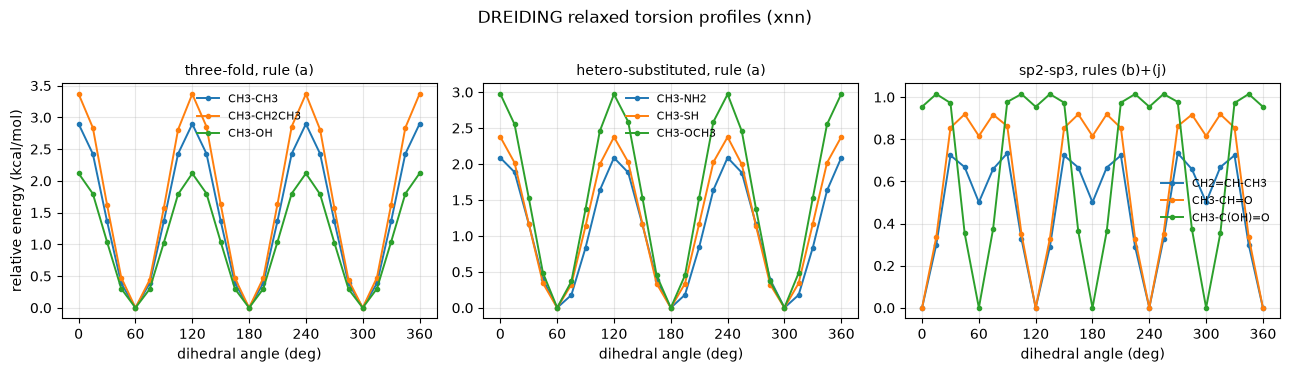

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)
panels = [
    ("three-fold, rule (a)", ["CH3-CH3", "CH3-CH2CH3", "CH3-OH"]),
    ("hetero-substituted, rule (a)", ["CH3-NH2", "CH3-SH", "CH3-OCH3"]),
    ("sp2-sp3, rules (b)+(j)", ["CH2=CH-CH3", "CH3-CH=O", "CH3-C(OH)=O"]),
]
for ax, (title, names) in zip(axes, panels):
    for name in names:
        p, e = profiles[name]
        ax.plot(p, e, marker="o", ms=3, lw=1.4, label=name)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("dihedral angle (deg)")
    ax.set_xticks([0, 60, 120, 180, 240, 300, 360])
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, frameon=False)
axes[0].set_ylabel("relative energy (kcal/mol)")
fig.suptitle("DREIDING relaxed torsion profiles (xnn)", y=1.02)
fig.tight_layout()
plt.savefig("dreiding_torsion_profiles.png", dpi=130, bbox_inches="tight")
plt.show()

Rule (a) gives clean three-fold profiles with minima at 60, 180 and 300
degrees. The sp2-sp3 panel is the interesting one: propene's profile is a
superposition of the six-fold rule (b) term (its outer atom on the sp2 side
is the other sp2 carbon) and the three-fold rule (j) term (outer hydrogens),
which is the "propene exception" of eq 23 -- introduced, in the paper's
words, because "for a system such as propene there is a 3-fold barrier with
the sp3 center eclipsing the double bond, whereas for the CC bond, say, of
acetate anion the barrier should have 6-fold character".

## 5. Amide rotation: when the typing carries the chemistry

Table XI's last two rows are the amide barriers, 18 and 19.6 kcal/mol
measured. Nothing in the DREIDING rules can produce a barrier that large
from an sp2 carbon bonded to an sp3 nitrogen: that combination is rule (b),
worth 1 kcal/mol. The resonance has to enter through the *typing* -- the
paper's footnote 8 explains that a nitrogen or oxygen whose lone pair
conjugates with a neighbouring pi system "is described as N_R or O_R" -- and
then rule (d) (eq 17, bond order 1.5, 25 kcal/mol) applies.

This is worth showing explicitly, because it is a case where the answer
depends on a chemical judgement the automatic perception does not make.

In [6]:
mol, atoms = embed("NC=O")
auto = Dreiding.from_atoms(mol, "dreiding", cutoff=20.0)
print("formamide, automatic typing (RDKit bond orders)")
print("  types ", auto.topology.types)
print("  orders", auto.topology.bond_orders)
print("  torsion rules:", sorted({RULE_IDS[int(r)] for r in auto.dihedral_rule}))

# the resonant description: C_R-N_R with bond order 1.5 (paper footnote 8)
sym = [a.GetSymbol() for a in mol.GetAtoms()]
types = []
for i, s in enumerate(sym):
    if s == "N":
        types.append("N_R")
    elif s == "C":
        types.append("C_R")
    elif s == "O":
        types.append("O_2")
    else:
        nb = mol.GetAtomWithIdx(i).GetNeighbors()
        types.append("H__HB" if any(x.GetSymbol() == "N" for x in nb) else "H_")
bonds = perceive_bonds(mol)
orders = [1.5 if {sym[i], sym[j]} == {"C", "N"}
          else (2.0 if {sym[i], sym[j]} == {"C", "O"} else 1.0)
          for i, j in bonds]
res_top = MolecularTopology.from_bonds(types, bonds, bond_orders=orders)
res = Dreiding("dreiding", res_top, cutoff=20.0)
print("\nformamide, resonant amide typing")
print("  types ", types)
print("  orders", orders)
print("  torsion rules:", sorted({RULE_IDS[int(r)] for r in res.dihedral_rule}))

for tag, m in (("automatic (C_2-N_3, rule b)", auto),
               ("resonant  (C_R-N_R, rule d)", res)):
    _, prof, _ = relaxed_scan(None, model=m, mol=mol, atoms=atoms)
    print(f"  {tag}: barrier {prof.max():7.3f} kcal/mol")
print("\n  paper Table XI, NH2-CHO: 24.506 calculated, 18(3) measured")

formamide, automatic typing (RDKit bond orders)
  types  ['N_3', 'C_2', 'O_2', 'H__HB', 'H__HB', 'H_']
  orders [1.0, 1.0, 1.0, 2.0, 1.0]
  torsion rules: ['b', 'j']

formamide, resonant amide typing
  types  ['N_R', 'C_R', 'O_2', 'H__HB', 'H__HB', 'H_']
  orders [1.5, 1.0, 1.0, 2.0, 1.0]
  torsion rules: ['d']


  automatic (C_2-N_3, rule b): barrier   1.163 kcal/mol


  resonant  (C_R-N_R, rule d): barrier  24.919 kcal/mol

  paper Table XI, NH2-CHO: 24.506 calculated, 18(3) measured


The resonant description lands on the paper's calculated barrier, and the
automatic one does not -- as it should not, since it describes a different
molecule. The practical lesson for anyone using this model: for amides,
conjugated heteroatoms and other resonance-delocalized bonds, set the atom
types and bond orders explicitly rather than relying on perception.

## 6. Table XII: conformational energies

Table XII asks a different question: not the height of a barrier but the
energy difference between two minima. Two entries are reproduced here --
the archetypal acyclic case (butane) and the archetypal cyclic one
(cyclohexane).

In [7]:
# --- butane gauche vs anti -------------------------------------------------
mol, atoms = embed("CCCC")
heavy = [a.GetIdx() for a in mol.GetAtoms() if a.GetAtomicNum() > 1]
quad = tuple(heavy[:4])
model = Dreiding.from_atoms(mol, "dreiding", cutoff=20.0)
calc = XNNCalculator(ForceStressOutput(model), cutoff=20.0)
mask = side_mask(mol, quad[1], quad[2])
ref = atoms.copy()
ref.calc = calc
BFGS(ref, logfile=None).run(fmax=1e-3, steps=800)


def at_dihedral(phi):
    a = ref.copy()
    a.calc = calc
    a.set_dihedral(*quad, phi, mask=mask)
    a.set_constraint(FixInternals(dihedrals_deg=[[phi, list(quad)]], epsilon=1e-8))
    BFGS(a, logfile=None).run(fmax=1e-3, steps=800)
    return a.get_potential_energy() * EV_TO_KCAL


e_gauche = min(at_dihedral(p) for p in (58.0, 62.0, 65.0, 68.0, 72.0))
e_anti = at_dihedral(180.0)
print(f"butane gauche - anti : {e_gauche - e_anti:.3f} kcal/mol   "
      f"(paper 0.75 calculated, 0.76 measured)")

butane gauche - anti : 0.727 kcal/mol   (paper 0.75 calculated, 0.76 measured)


In [8]:
# --- cyclohexane: chair vs twist-boat --------------------------------------
# both basins are found by minimizing a pool of RDKit conformers; the two
# distinct energies that survive are the chair and the twist-boat
mol = Chem.AddHs(Chem.MolFromSmiles("C1CCCCC1"))
cids = AllChem.EmbedMultipleConfs(mol, numConfs=120, randomSeed=0xBEEF)
AllChem.MMFFOptimizeMoleculeConfs(mol)
model = Dreiding.from_atoms(mol, "dreiding", cutoff=20.0)
calc = XNNCalculator(ForceStressOutput(model), cutoff=20.0)
z = [a.GetAtomicNum() for a in mol.GetAtoms()]
es = []
for cid in cids:
    c = mol.GetConformer(cid)
    p = np.array([list(c.GetAtomPosition(i)) for i in range(mol.GetNumAtoms())])
    a = Atoms(numbers=z, positions=p)
    a.calc = calc
    BFGS(a, logfile=None).run(fmax=1e-3, steps=800)
    es.append(a.get_potential_energy() * EV_TO_KCAL)
es = np.sort(np.array(es))
es -= es[0]
basins = [es[0]]
for e in es[1:]:
    if e - basins[-1] > 0.05:
        basins.append(e)
print(f"{len(cids)} conformers minimized -> distinct basins (kcal/mol above chair): "
      f"{np.round(basins, 3)}")
print(f"cyclohexane twist-boat - chair : {basins[1]:.3f} kcal/mol   "
      f"(paper 7.72 calculated, 5.7 measured)")

120 conformers minimized -> distinct basins (kcal/mol above chair): [0.    7.698]
cyclohexane twist-boat - chair : 7.698 kcal/mol   (paper 7.72 calculated, 5.7 measured)


## 7. Summary

| quantity | `xnn` | DREIDING (paper) | experiment |
|---|---|---|---|
| 14 single-bond rotational barriers (Table XI) | see table above | mean \|difference\| from `xnn` ≈ 0.02 kcal/mol | mean \|DREIDING − exp\| ≈ 0.6 kcal/mol |
| formamide rotation, resonant typing | ≈ 24.9 | 24.506 | 18(3) |
| butane gauche − anti (Table XII) | ≈ 0.73 | 0.75 | 0.76 |
| cyclohexane twist-boat − chair (Table XII) | ≈ 7.70 | 7.72 | 5.7 |

The implementation reproduces the paper's own numbers across barriers that
span rules (a), (b), (d), (h), (i) and (j) and two conformational
equilibria, which is an end-to-end check of the rule engine that no
term-by-term comparison can give. Where DREIDING disagrees with experiment
it does so in the way the paper documents, not in a new way.

For the numerical verification of the energy expressions themselves against
an independent implementation, see
`examples/fidelity_checks/dreiding_verification.ipynb`. For refitting the
generators to new reference data, see `dreiding_refit_aromatics.ipynb`.